<a href="https://colab.research.google.com/github/NiharikaChavan/texture/blob/main/Texture_Synthesis_11April.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.2/85.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 23.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.11.0.86
    Uninstalling opencv-python-headless-4.11.0.86:
      Successfully uninstalled opencv-python-headless-4.11.0.86
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10


In [2]:
from roboflow import Roboflow
import os
import glob

def download_roboflow_dataset(api_key, workspace_id, project_id, version_id):
    """Download a dataset from Roboflow in YOLOv11 format"""
    rf = Roboflow(api_key=api_key)
    project = rf.workspace(workspace_id).project(project_id)

    # Modified line to download YOLOv11 format instead of COCO
    dataset = project.version(version_id).download("yolov11")  # Roboflow typically uses "yolov5" label format for YOLOv5/v7/v8/v11

    print(f"Dataset downloaded to: {dataset.location}")
    return dataset.location

# Security note: Remove API key before sharing code
api_key = "SN5wJh6Iq1qReYz1KzDq"
workspace_id = "interiorfurniture"
project_id = "chair-eecyt"
version_id = 1

# Download the dataset
dataset_path = download_roboflow_dataset(api_key, workspace_id, project_id, version_id)

# Define output path
output_path = "./texture_output"
os.makedirs(output_path, exist_ok=True)

# Explore the dataset structure
print("\nExploring YOLO dataset structure:")
print("Root directory contents:")
for item in glob.glob(f"{dataset_path}/*"):
    print(f"- {os.path.basename(item)}")

# YOLO datasets use .txt annotations instead of .json
print("\nLooking for YOLO annotation files:")
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".txt"):
            print(f"Found YOLO annotation file: {os.path.join(root, file)}")

# Check dataset.yaml file
print("\nLooking for dataset YAML file:")
if os.path.exists(os.path.join(dataset_path, "data.yaml")):
    print("Found data.yaml - this is crucial for YOLO training")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to chair-1 in yolov11:: 100%|██████████| 290/290 [00:00<00:00, 1236.81it/s]

Dataset downloaded to: /content/chair-1

Exploring YOLO dataset structure:
Root directory contents:
- README.roboflow.txt
- data.yaml
- valid
- test
- README.dataset.txt
- train

Looking for YOLO annotation files:
Found YOLO annotation file: /content/chair-1/README.roboflow.txt
Found YOLO annotation file: /content/chair-1/README.dataset.txt
Found YOLO annotation file: /content/chair-1/valid/labels/IMG_20250411_125026_jpg.rf.c5ab59c027342b346cc4b6996fda67e9.txt
Found YOLO annotation file: /content/chair-1/valid/labels/IMG_20250411_125041_jpg.rf.e6fa07b0d29711155880d10bb0b7f6db.txt
Found YOLO annotation file: /content/chair-1/valid/labels/IMG_20250411_125105__01_jpg.rf.740a53404eaf5e45f2aa7e74562ec755.txt
Found YOLO annotation file: /content/chair-1/valid/labels/IMG_20250411_125016_jpg.rf.98031ee3720744f2b55e0df3ec7a45ca.txt
Found YOLO annotation file: /content/chair-1/valid/labels/IMG_20250411_124959_jpg.rf.b6adce315b62ec6ea7e7ae8d7f86f279.txt
Found YOLO annotation file: /content/chair-

In [3]:
from roboflow import Roboflow
import os
import glob

def download_roboflow_dataset(api_key, workspace_id, project_id, version_id):
    """Download a dataset from Roboflow and return its path"""
    rf = Roboflow(api_key=api_key)
    project = rf.workspace(workspace_id).project(project_id)
    dataset = project.version(version_id).download("coco-segmentation")  # Use COCO format for segmentation
    print(f"Dataset downloaded to: {dataset.location}")
    return dataset.location

api_key = "SN5wJh6Iq1qReYz1KzDq"
workspace_id = "interiorfurniture"
project_id = "chair-eecyt"
version_id = 1

# Download the dataset
dataset_path = download_roboflow_dataset(api_key, workspace_id, project_id, version_id)

# Define output path
output_path = "./texture_output"
os.makedirs(output_path, exist_ok=True)

# Explore the dataset structure
print("\nExploring dataset structure:")
print("Root directory contents:")
for item in glob.glob(f"{dataset_path}/*"):
    print(f"- {os.path.basename(item)}")

# Look for annotation files
print("\nLooking for annotation files:")
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".json"):
            print(f"Found JSON file: {os.path.join(root, file)}")

# Look for test directory structure
print("\nLooking for test directory:")
if os.path.exists(os.path.join(dataset_path, "test")):
    print("Test directory exists")
    print("Contents of test directory:")
    for item in glob.glob(f"{dataset_path}/test/*"):
        print(f"- {os.path.basename(item)}")
else:
    print("Test directory not found, checking other directories")
    for dir in glob.glob(f"{dataset_path}/*"):
        if os.path.isdir(dir):
            print(f"Contents of {os.path.basename(dir)} directory:")
            for item in glob.glob(f"{dir}/*"):
                print(f"- {os.path.basename(item)}")

loading Roboflow workspace...
loading Roboflow project...
Exporting format coco-segmentation in progress : 85.0%
Version export complete for coco-segmentation format
Dataset downloaded to: /content/chair-1

Exploring dataset structure:
Root directory contents:
- README.roboflow.txt
- data.yaml
- valid
- test
- README.dataset.txt
- train

Looking for annotation files:

Looking for test directory:
Test directory exists
Contents of test directory:
- images
- labels


In [4]:
!pip install diffusers==0.23.1 transformers==4.34.0 accelerate==0.23.0 controlnet_aux==0.0.6 torch torchvision opencv-python
!pip install pycocotools

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.5/121.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.1/258.1 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.9/261.9 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 110.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 89.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [5]:
dataset_path

'/content/chair-1'

In [6]:
import os
import glob
import yaml
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

# Define the dataset path
dataset_path = "/content/chair-1"
test_dir = os.path.join(dataset_path, "test")
images_dir = os.path.join(test_dir, "images")
labels_dir = os.path.join(test_dir, "labels")

# Define output path
output_path = "./texture_output"
os.makedirs(output_path, exist_ok=True)

# Print directory structure
print(f"Dataset path: {dataset_path}")
print(f"Test images path: {images_dir}")
print(f"Test labels path: {labels_dir}")

# List images and labels
image_files = sorted(glob.glob(os.path.join(images_dir, "*.jpg")) +
                     glob.glob(os.path.join(images_dir, "*.jpeg")) +
                     glob.glob(os.path.join(images_dir, "*.png")))
label_files = sorted(glob.glob(os.path.join(labels_dir, "*.txt")))

print(f"\nFound {len(image_files)} image files")
print(f"Found {len(label_files)} label files")

# Load class names from data.yaml
data_yaml_path = os.path.join(dataset_path, "data.yaml")
class_names = []
if os.path.exists(data_yaml_path):
    with open(data_yaml_path, 'r') as file:
        data_yaml = yaml.safe_load(file)
        class_names = data_yaml.get('names', [])
        print("\nClass names from data.yaml:")
        for idx, name in enumerate(class_names):
            print(f"{idx}: {name}")
else:
    print("Warning: data.yaml not found. Class names will be numbered.")

# If no class names were found, create a default list
if not class_names:
    class_names = [f"class_{i}" for i in range(80)]  # Default to 80 classes (COCO standard)

Dataset path: /content/chair-1
Test images path: /content/chair-1/test/images
Test labels path: /content/chair-1/test/labels

Found 7 image files
Found 7 label files

Class names from data.yaml:
0: chairs
1: metal
2: plastic
3: upholstery


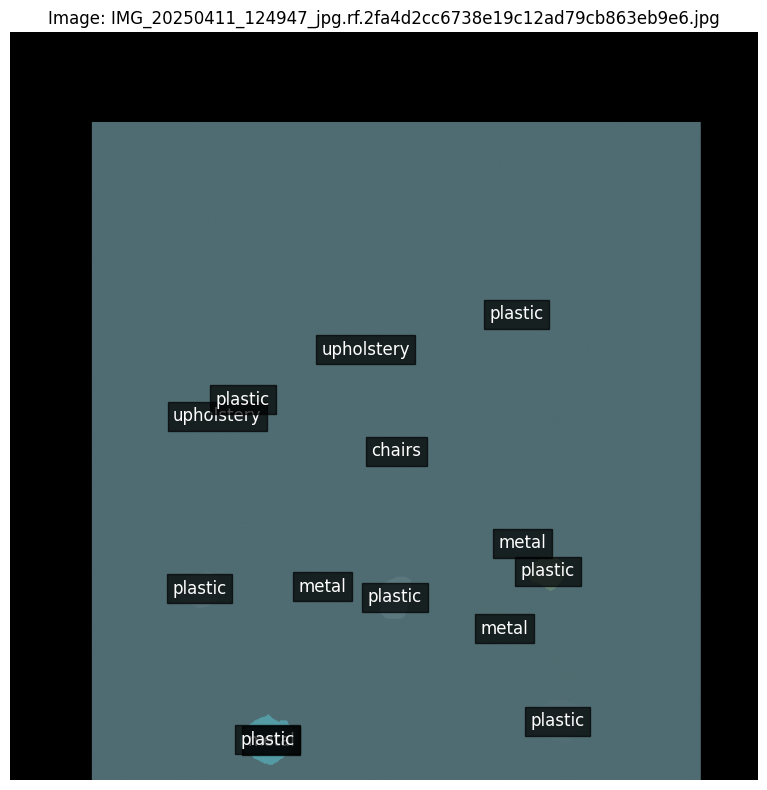

In [7]:
def read_yolo_seg_file(file_path, img_width, img_height):
    """Read YOLO segmentation file and return list of masks and class ids"""
    masks = []
    class_ids = []

    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:  # Need at least class_id and 2 points (4 values)
                continue

            class_id = int(parts[0])
            class_ids.append(class_id)

            # Convert polygon points from normalized to absolute coordinates
            polygon = []
            for i in range(1, len(parts), 2):
                if i+1 < len(parts):
                    x = float(parts[i]) * img_width
                    y = float(parts[i+1]) * img_height
                    polygon.append((x, y))

            # Create mask from polygon
            mask = np.zeros((img_height, img_width), dtype=np.uint8)
            polygon_np = np.array(polygon, np.int32).reshape((-1, 1, 2))
            cv2.fillPoly(mask, [polygon_np], 1)
            masks.append(mask)

    return masks, class_ids

# Display a sample image with masks
def display_sample_with_masks(img_idx=0):
    if len(image_files) <= img_idx:
        print("No image found at the specified index")
        return None, None, None

    img_path = image_files[img_idx]
    img_name = os.path.basename(img_path)
    base_name = os.path.splitext(img_name)[0]
    label_path = os.path.join(labels_dir, base_name + '.txt')

    if not os.path.exists(label_path):
        print(f"Label file not found: {label_path}")
        return None, None, None

    # Load image
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    img_height, img_width = image.shape[:2]

    # Load masks
    masks, class_ids = read_yolo_seg_file(label_path, img_width, img_height)

    # Display image with masks
    plt.figure(figsize=(12, 8))
    plt.imshow(image)

    # Draw masks with different colors
    colors = plt.cm.tab20(np.linspace(0, 1, max(len(masks), 1)))
    for i, (mask, class_id) in enumerate(zip(masks, class_ids)):
        color_mask = np.zeros((img_height, img_width, 3))
        color_rgba = colors[i % len(colors)][:3]  # Get RGB part of RGBA
        for c in range(3):
            color_mask[:,:,c] = mask * color_rgba[c]

        plt.imshow(color_mask, alpha=0.5)

        # Get class name and add label
        class_name = class_names[class_id] if class_id < len(class_names) else f"Class {class_id}"

        # Find mask center for label placement
        y_indices, x_indices = np.where(mask > 0)
        if len(y_indices) > 0 and len(x_indices) > 0:
            center_y = int(np.mean(y_indices))
            center_x = int(np.mean(x_indices))
            plt.text(center_x, center_y, class_name, color='white',
                     fontsize=12, ha='center', va='center',
                     bbox=dict(facecolor='black', alpha=0.7))

    plt.title(f"Image: {img_name}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return image, masks, class_ids

# Display first sample image
image, masks, class_ids = display_sample_with_masks(0)

In [8]:
# Install packages without strict version constraints
!pip install -U "diffusers[torch]" controlnet_aux accelerate transformers
!pip install opencv-python clip ftfy regex tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 282.4/282.4 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.7/354.7 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 481.4/481.4 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.0/510.0 kB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 52.5 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface-hub 0.17.3
    Uninstalling huggingface-hub-0.17.3:
      Successfully uninstalled huggingface-hub-0.17.3
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.14.1
    Uninstalling tokenizers-0.14.1:
      Successfully uninstalled tokenizers-0.14.1
  Attempting uninstall: diffusers
    Found existing installation: diffusers 0.23

In [9]:
# Install PyYAML (not yaml)
!pip install PyYAML

In [10]:
import torch
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel, UniPCMultistepScheduler
from controlnet_aux import MidasDetector, HEDdetector

# Initialize ControlNet auxiliary models - with updated repo sources
print("Loading ControlNet auxiliary models...")

try:
    # Try to load Midas depth detector
    midas = MidasDetector.from_pretrained("lllyasviel/Annotators")
    print("✓ MidasDetector loaded successfully")
except Exception as e:
    print(f"Error loading MidasDetector: {e}")
    print("Trying alternative source...")
    try:
        midas = MidasDetector.from_pretrained("patrickvonplaten/controlnet_aux")
        print("✓ MidasDetector loaded from alternative source")
    except Exception as e:
        print(f"Failed to load MidasDetector from alternative source: {e}")
        midas = None

try:
    # Try to load HED edge detector
    hed = HEDdetector.from_pretrained("lllyasviel/Annotators")
    print("✓ HEDdetector loaded successfully")
except Exception as e:
    print(f"Error loading HEDdetector: {e}")
    print("Trying alternative source...")
    try:
        hed = HEDdetector.from_pretrained("patrickvonplaten/controlnet_aux")
        print("✓ HEDdetector loaded from alternative source")
    except Exception as e:
        print(f"Failed to load HEDdetector from alternative source: {e}")
        hed = None

# Skip if the auxiliary models couldn't be loaded
if midas is None or hed is None:
    print("Failed to load one or more auxiliary models. Cannot continue with ControlNet.")
else:
    # Initialize ControlNet models
    print("Loading ControlNet models...")

    try:
        # Try to load depth ControlNet
        controlnet_depth = ControlNetModel.from_pretrained(
            "lllyasviel/sd-controlnet-depth", torch_dtype=torch.float16
        )
        print("✓ Depth ControlNet loaded successfully")
    except Exception as e:
        print(f"Error loading Depth ControlNet: {e}")
        print("Trying alternative source...")
        try:
            controlnet_depth = ControlNetModel.from_pretrained(
                "runwayml/stable-diffusion-v1-5-controlnet-depth", torch_dtype=torch.float16
            )
            print("✓ Depth ControlNet loaded from alternative source")
        except Exception as e:
            print(f"Failed to load Depth ControlNet from alternative source: {e}")
            controlnet_depth = None

    try:
        # Try to load edge ControlNet
        controlnet_hed = ControlNetModel.from_pretrained(
            "lllyasviel/sd-controlnet-hed", torch_dtype=torch.float16
        )
        print("✓ HED ControlNet loaded successfully")
    except Exception as e:
        print(f"Error loading HED ControlNet: {e}")
        print("Trying alternative source...")
        try:
            controlnet_hed = ControlNetModel.from_pretrained(
                "runwayml/stable-diffusion-v1-5-controlnet-hed", torch_dtype=torch.float16
            )
            print("✓ HED ControlNet loaded from alternative source")
        except Exception as e:
            print(f"Failed to load HED ControlNet from alternative source: {e}")
            controlnet_hed = None

    # Skip if the ControlNet models couldn't be loaded
    if controlnet_depth is None or controlnet_hed is None:
        print("Failed to load one or more ControlNet models. Cannot continue with ControlNet pipeline.")
    else:
        # Initialize Stable Diffusion pipeline
        print("Loading Stable Diffusion pipeline...")

        try:
            pipe = StableDiffusionControlNetPipeline.from_pretrained(
                "runwayml/stable-diffusion-v1-5",
                controlnet=[controlnet_depth, controlnet_hed],
                safety_checker=None,
                torch_dtype=torch.float16
            )

            # Configure pipeline
            pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)
            pipe.enable_model_cpu_offload()
            pipe.enable_vae_slicing()
            print("✓ Models loaded successfully!")

        except Exception as e:
            print(f"Error initializing Stable Diffusion ControlNet pipeline: {e}")
            print("Will need to use an alternative approach.")

The module 'mediapipe' is not installed. The package will have limited functionality. Please install it using the command: pip install 'mediapipe'


Loading ControlNet auxiliary models...



The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.


dpt_hybrid-midas-501f0c75.pt:   0%|          | 0.00/493M [00:00<?, ?B/s]

✓ MidasDetector loaded successfully


ControlNetHED.pth:   0%|          | 0.00/29.4M [00:00<?, ?B/s]

✓ HEDdetector loaded successfully
Loading ControlNet models...
Error loading Depth ControlNet: Can't load config for 'lllyasviel/sd-controlnet-depth'. If you were trying to load it from 'https://huggingface.co/models', make sure you don't have a local directory with the same name. Otherwise, make sure 'lllyasviel/sd-controlnet-depth' is the correct path to a directory containing a config.json file
Trying alternative source...
Failed to load Depth ControlNet from alternative source: runwayml/stable-diffusion-v1-5-controlnet-depth is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo with `token` or log in with `huggingface-cli login`.


config.json:   0%|          | 0.00/920 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.45G [00:00<?, ?B/s]

✓ HED ControlNet loaded successfully
Failed to load one or more ControlNet models. Cannot continue with ControlNet pipeline.


In [11]:
!pip install transformers accelerate pillow

In [12]:
import torch
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image

# Set up the image-to-text model (BLIP2)
print("Loading BLIP2 image-to-text model...")
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-large")
captioning_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-large", torch_dtype=torch.float16)
device = "cuda" if torch.cuda.is_available() else "cpu"
captioning_model = captioning_model.to(device)
print(f"BLIP2 model loaded and moved to {device}")

# Function to generate descriptive prompt from an image
def generate_description_from_image(image_array, class_name):
    """Generate a descriptive caption for the image and enhance it for texture generation"""

    # Convert to PIL image
    pil_image = Image.fromarray(image_array)

    # Prepare inputs for the model
    # Include a text prompt in the processor step instead
    text_prompt = f"a photo of {class_name}, describe the texture, material and surface details"
    inputs = processor(pil_image, text_prompt, return_tensors="pt").to(device)

    # Generate caption
    with torch.no_grad():
        # Generate without the invalid 'prompt' parameter
        out = captioning_model.generate(
            **inputs,
            max_length=150,
            num_beams=5,
            min_length=30,
            do_sample=True,  # Enable sampling to use top_p
            top_p=0.9,
            repetition_penalty=1.5
        )

    # Decode the caption
    caption = processor.decode(out[0], skip_special_tokens=True)

    # Enhance caption for texture generation
    # Add specific keywords to focus on texture aspects
    enhanced_prompt = f"{caption}, {class_name} texture, detailed, realistic, high quality, photorealistic"

    return enhanced_prompt

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Loading BLIP2 image-to-text model...


preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/527 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.60k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.88G [00:00<?, ?B/s]

BLIP2 model loaded and moved to cuda



Class names from data.yaml:
0: chairs
1: metal
2: plastic
3: upholstery


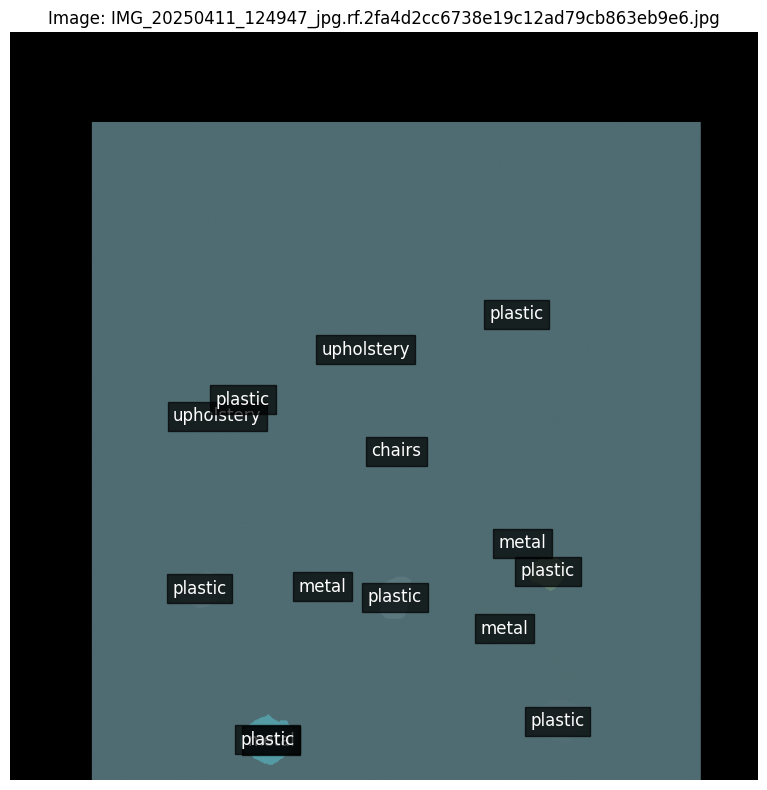

In [13]:
import os
import numpy as np
import cv2
import glob
import yaml
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Function to read YOLO segmentation file
def read_yolo_seg_file(file_path, img_width, img_height):
    """Read YOLO segmentation file and return list of masks and class ids"""
    masks = []
    class_ids = []

    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:  # Need at least class_id and 2 points (4 values)
                continue

            class_id = int(parts[0])
            class_ids.append(class_id)

            # Convert polygon points from normalized to absolute coordinates
            polygon = []
            for i in range(1, len(parts), 2):
                if i+1 < len(parts):
                    x = float(parts[i]) * img_width
                    y = float(parts[i+1]) * img_height
                    polygon.append((x, y))

            # Create mask from polygon
            mask = np.zeros((img_height, img_width), dtype=np.uint8)
            polygon_np = np.array(polygon, np.int32).reshape((-1, 1, 2))
            cv2.fillPoly(mask, [polygon_np], 1)
            masks.append(mask)

    return masks, class_ids

# Function to display a sample image with masks
def display_sample_with_masks(image_idx=0, class_names=[]):
    # Get dataset paths
    dataset_path = "/content/chair-1"
    test_dir = os.path.join(dataset_path, "test")
    images_dir = os.path.join(test_dir, "images")
    labels_dir = os.path.join(test_dir, "labels")

    # List images
    image_files = sorted(glob.glob(os.path.join(images_dir, "*.jpg")) +
                     glob.glob(os.path.join(images_dir, "*.jpeg")) +
                     glob.glob(os.path.join(images_dir, "*.png")))

    if len(image_files) <= image_idx:
        print("No image found at the specified index")
        return None, None, None

    img_path = image_files[image_idx]
    img_name = os.path.basename(img_path)
    base_name = os.path.splitext(img_name)[0]
    label_path = os.path.join(labels_dir, base_name + '.txt')

    if not os.path.exists(label_path):
        print(f"Label file not found: {label_path}")
        return None, None, None

    # Load image
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    img_height, img_width = image.shape[:2]

    # Load masks
    masks, class_ids = read_yolo_seg_file(label_path, img_width, img_height)

    # Display image with masks
    plt.figure(figsize=(12, 8))
    plt.imshow(image)

    # Draw masks with different colors
    colors = plt.cm.tab20(np.linspace(0, 1, max(len(masks), 1)))
    for i, (mask, class_id) in enumerate(zip(masks, class_ids)):
        color_mask = np.zeros((img_height, img_width, 3))
        color_rgba = colors[i % len(colors)][:3]  # Get RGB part of RGBA
        for c in range(3):
            color_mask[:,:,c] = mask * color_rgba[c]

        plt.imshow(color_mask, alpha=0.5)

        # Get class name and add label
        class_name = class_names[class_id] if class_id < len(class_names) else f"Class {class_id}"

        # Find mask center for label placement
        y_indices, x_indices = np.where(mask > 0)
        if len(y_indices) > 0 and len(x_indices) > 0:
            center_y = int(np.mean(y_indices))
            center_x = int(np.mean(x_indices))
            plt.text(center_x, center_y, class_name, color='white',
                     fontsize=12, ha='center', va='center',
                     bbox=dict(facecolor='black', alpha=0.7))

    plt.title(f"Image: {img_name}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return image, masks, class_ids

# Load class names from data.yaml
def load_class_names():
    dataset_path = "/content/chair-1"
    data_yaml_path = os.path.join(dataset_path, "data.yaml")
    class_names = []
    if os.path.exists(data_yaml_path):
        with open(data_yaml_path, 'r') as file:
            data_yaml = yaml.safe_load(file)
            class_names = data_yaml.get('names', [])
            print("\nClass names from data.yaml:")
            for idx, name in enumerate(class_names):
                print(f"{idx}: {name}")
    else:
        print("Warning: data.yaml not found. Class names will be numbered.")
        class_names = [f"class_{i}" for i in range(80)]  # Default to 80 classes

    return class_names

# Load class names
class_names = load_class_names()

# Display a sample image with masks
image, masks, class_ids = display_sample_with_masks(0, class_names)

In [14]:
def generate_textures_with_auto_prompts(image_idx=0):
    """Generate textures for all segmented parts using automatically generated prompts"""

    # Get dataset paths
    dataset_path = "/content/chair-1"
    test_dir = os.path.join(dataset_path, "test")
    images_dir = os.path.join(test_dir, "images")
    labels_dir = os.path.join(test_dir, "labels")

    # Define output path
    output_path = "./texture_output_auto"
    os.makedirs(output_path, exist_ok=True)

    # List images
    image_files = sorted(glob.glob(os.path.join(images_dir, "*.jpg")) +
                         glob.glob(os.path.join(images_dir, "*.jpeg")) +
                         glob.glob(os.path.join(images_dir, "*.png")))

    if image_idx >= len(image_files):
        print(f"Error: Image index {image_idx} out of range. Only {len(image_files)} images available.")
        return None

    # Get image and label paths
    img_path = image_files[image_idx]
    img_name = os.path.basename(img_path)
    base_name = os.path.splitext(img_name)[0]
    label_path = os.path.join(labels_dir, base_name + '.txt')

    if not os.path.exists(label_path):
        print(f"Error: Label file not found: {label_path}")
        return None

    # Load image
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    img_height, img_width = image.shape[:2]

    # Create output directory
    img_output_dir = os.path.join(output_path, base_name)
    os.makedirs(img_output_dir, exist_ok=True)

    # Save original image
    Image.fromarray(image).save(os.path.join(img_output_dir, "original.png"))

    # Load masks
    masks, class_ids = read_yolo_seg_file(label_path, img_width, img_height)

    # Create a copy for the final composite
    composite = image.copy()

    # Process each segment
    print(f"Processing {len(masks)} segments in image {img_name}...")

    with open(os.path.join(img_output_dir, "log.txt"), "w") as log_file:
        log_file.write(f"Processing image: {img_name}\n")
        log_file.write(f"Number of segments: {len(masks)}\n\n")

        for i, (mask, class_id) in enumerate(tqdm(zip(masks, class_ids), total=len(masks))):
            # Get class name
            class_name = class_names[class_id] if class_id < len(class_names) else f"class_{class_id}"

            log_file.write(f"Segment {i+1}: Class {class_id} ({class_name})\n")

            # Create masked image
            masked_image = image.copy()
            for c in range(3):
                masked_image[:, :, c] = masked_image[:, :, c] * mask

            # Save masked instance
            instance_path = os.path.join(img_output_dir, f"{class_name}_{i}_instance.png")
            Image.fromarray(masked_image).save(instance_path)

            # Generate auto prompt using image-to-text model
            prompt = generate_description_from_image(masked_image, class_name)
            log_file.write(f"  Auto-generated prompt: {prompt}\n")

            try:
                # Generate control images
                masked_pil = Image.fromarray(masked_image)
                depth_image = midas(masked_pil)
                edge_image = hed(masked_pil)

                # Save control images
                depth_path = os.path.join(img_output_dir, f"{class_name}_{i}_depth.png")
                edge_path = os.path.join(img_output_dir, f"{class_name}_{i}_edge.png")
                depth_image.save(depth_path)
                edge_image.save(edge_path)

                # Generate texture using ControlNet
                result = pipe(
                    prompt=prompt,
                    negative_prompt="blurry, distorted, low quality, lowres",
                    image=[depth_image, edge_image],
                    num_inference_steps=30,
                    guidance_scale=7.5,
                ).images[0]

                # Save raw texture
                raw_texture_path = os.path.join(img_output_dir, f"{class_name}_{i}_raw_texture.png")
                result.save(raw_texture_path)

                # Apply mask to texture
                result_array = np.array(result)

                # Resize result if needed
                if result_array.shape[:2] != (img_height, img_width):
                    result_array = cv2.resize(result_array, (img_width, img_height))

                masked_result = result_array.copy()
                for c in range(3):
                    masked_result[:, :, c] = masked_result[:, :, c] * mask

                # Save masked texture
                texture_path = os.path.join(img_output_dir, f"{class_name}_{i}_texture.png")
                Image.fromarray(masked_result).save(texture_path)

                # Apply to composite
                for c in range(3):
                    mask_area = mask > 0
                    composite[:, :, c][mask_area] = masked_result[:, :, c][mask_area]

                # Save intermediate composite
                intermediate_path = os.path.join(img_output_dir, f"composite_after_{i+1}.png")
                Image.fromarray(composite).save(intermediate_path)
                log_file.write(f"  Texture generated successfully\n")

            except Exception as e:
                log_file.write(f"  Error generating texture: {str(e)}\n")
                print(f"Error processing segment {i} ({class_name}): {e}")

        # Save final composite
        final_path = os.path.join(img_output_dir, "final_composite.png")
        Image.fromarray(composite).save(final_path)
        log_file.write("\nFinal composite saved.\n")
        print(f"Final composite saved to: {final_path}")

    return composite

In [15]:
def display_auto_results(image_idx=0):
    """Display the original and texture-applied images side by side"""

    # Get dataset paths
    dataset_path = "/content/chair-1"
    test_dir = os.path.join(dataset_path, "test")
    images_dir = os.path.join(test_dir, "images")

    # Define output path
    output_path = "./texture_output_auto"

    # List images
    image_files = sorted(glob.glob(os.path.join(images_dir, "*.jpg")) +
                         glob.glob(os.path.join(images_dir, "*.jpeg")) +
                         glob.glob(os.path.join(images_dir, "*.png")))

    if image_idx >= len(image_files):
        print(f"Error: Image index {image_idx} out of range.")
        return

    img_path = image_files[image_idx]
    img_name = os.path.basename(img_path)
    base_name = os.path.splitext(img_name)[0]

    # Get paths for original and composite images
    original_path = img_path
    composite_path = os.path.join(output_path, base_name, "final_composite.png")

    if not os.path.exists(composite_path):
        print(f"Error: Composite image not found at {composite_path}")
        return

    # Load images
    original = cv2.imread(original_path)
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

    composite = cv2.imread(composite_path)
    composite = cv2.cvtColor(composite, cv2.COLOR_BGR2RGB)

    # Display side by side
    plt.figure(figsize=(20, 10))

    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(composite)
    plt.title("Image with AI-Generated Textures")
    plt.axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(output_path, f"{base_name}_comparison.png"))
    plt.show()

    # Also print the prompts used
    log_path = os.path.join(output_path, base_name, "log.txt")
    if os.path.exists(log_path):
        with open(log_path, 'r') as f:
            log_lines = f.readlines()
            prompt_lines = [line for line in log_lines if "Auto-generated prompt" in line]
            print("Prompts used for texture generation:")
            for prompt in prompt_lines:
                print(prompt.strip())

Processing 14 segments in image IMG_20250411_124947_jpg.rf.2fa4d2cc6738e19c12ad79cb863eb9e6.jpg...


  0%|          | 0/14 [00:00<?, ?it/s]

Error processing segment 0 (upholstery): name 'pipe' is not defined
Error processing segment 1 (upholstery): name 'pipe' is not defined
Error processing segment 2 (plastic): name 'pipe' is not defined
Error processing segment 3 (plastic): name 'pipe' is not defined
Error processing segment 4 (metal): name 'pipe' is not defined
Error processing segment 5 (metal): name 'pipe' is not defined
Error processing segment 6 (metal): name 'pipe' is not defined
Error processing segment 7 (metal): name 'pipe' is not defined
Error processing segment 8 (plastic): name 'pipe' is not defined
Error processing segment 9 (plastic): name 'pipe' is not defined
Error processing segment 10 (plastic): name 'pipe' is not defined
Error processing segment 11 (plastic): name 'pipe' is not defined
Error processing segment 12 (plastic): name 'pipe' is not defined
Error processing segment 13 (chairs): name 'pipe' is not defined
Final composite saved to: ./texture_output_auto/IMG_20250411_124947_jpg.rf.2fa4d2cc6738e1

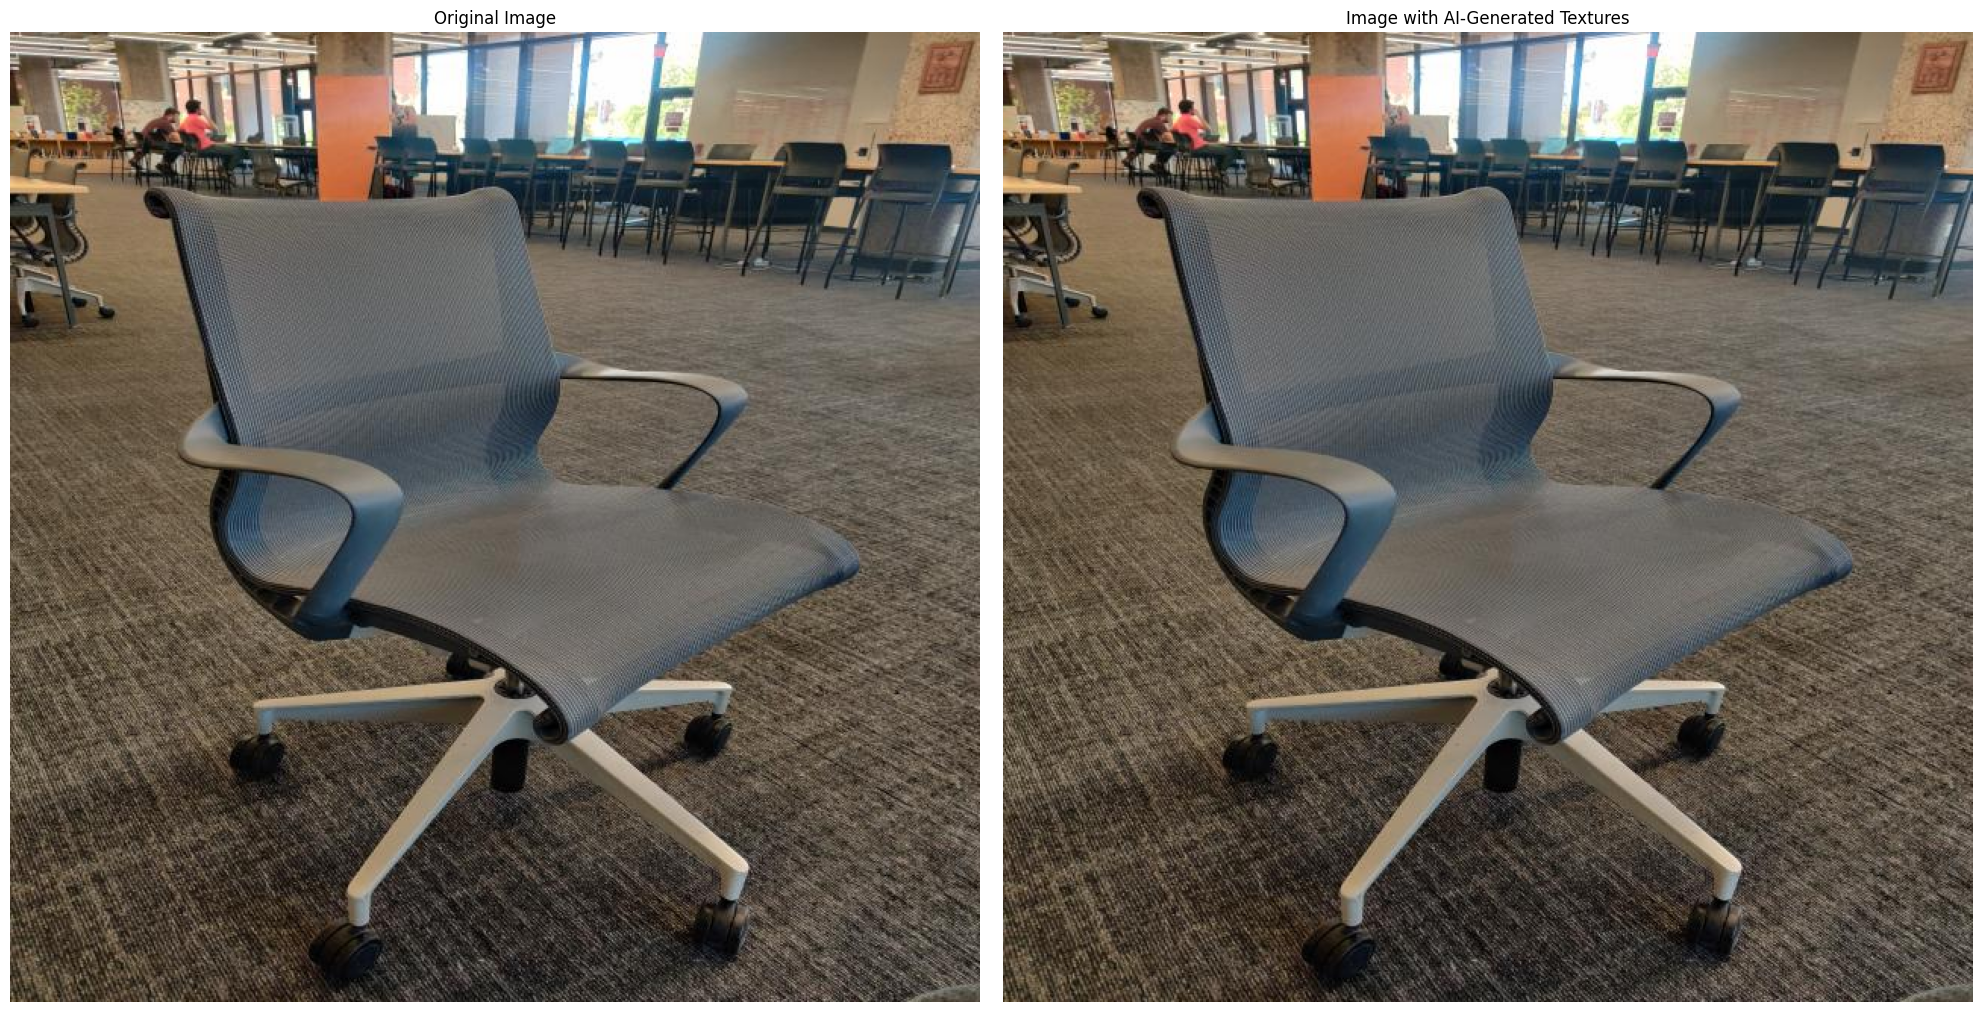

Prompts used for texture generation:
Auto-generated prompt: a photo of upholstery, describe the texture, material and surface details of an object in the night sky with a small hole in the middle, upholstery texture, detailed, realistic, high quality, photorealistic
Auto-generated prompt: a photo of upholstery, describe the texture, material and surface details of a chair with a curved back and seat that is made of polyure, upholstery texture, detailed, realistic, high quality, photorealistic
Auto-generated prompt: a photo of plastic, describe the texture, material and surface details of an object that appears to be floating in the air, with a black background, plastic texture, detailed, realistic, high quality, photorealistic
Auto-generated prompt: a photo of plastic, describe the texture, material and surface details of a piece of furniture in the shape of a curved arrow on a black background, plastic texture, detailed, realistic, high quality, photorealistic
Auto-generated prompt: a

In [16]:
# Process an image with auto-generated prompts
result = generate_textures_with_auto_prompts(0)
display_auto_results(0)

Processing 12 segments in image IMG_20250411_124949_jpg.rf.c41a28d6fb5727e963cfa153c976fee2.jpg...


  0%|          | 0/12 [00:00<?, ?it/s]

Error processing segment 0 (upholstery): name 'pipe' is not defined
Error processing segment 1 (upholstery): name 'pipe' is not defined
Error processing segment 2 (plastic): name 'pipe' is not defined
Error processing segment 3 (plastic): name 'pipe' is not defined
Error processing segment 4 (metal): name 'pipe' is not defined
Error processing segment 5 (metal): name 'pipe' is not defined
Error processing segment 6 (plastic): name 'pipe' is not defined
Error processing segment 7 (plastic): name 'pipe' is not defined
Error processing segment 8 (plastic): name 'pipe' is not defined
Error processing segment 9 (plastic): name 'pipe' is not defined
Error processing segment 10 (plastic): name 'pipe' is not defined
Error processing segment 11 (chairs): name 'pipe' is not defined
Final composite saved to: ./texture_output_auto/IMG_20250411_124949_jpg.rf.c41a28d6fb5727e963cfa153c976fee2/final_composite.png


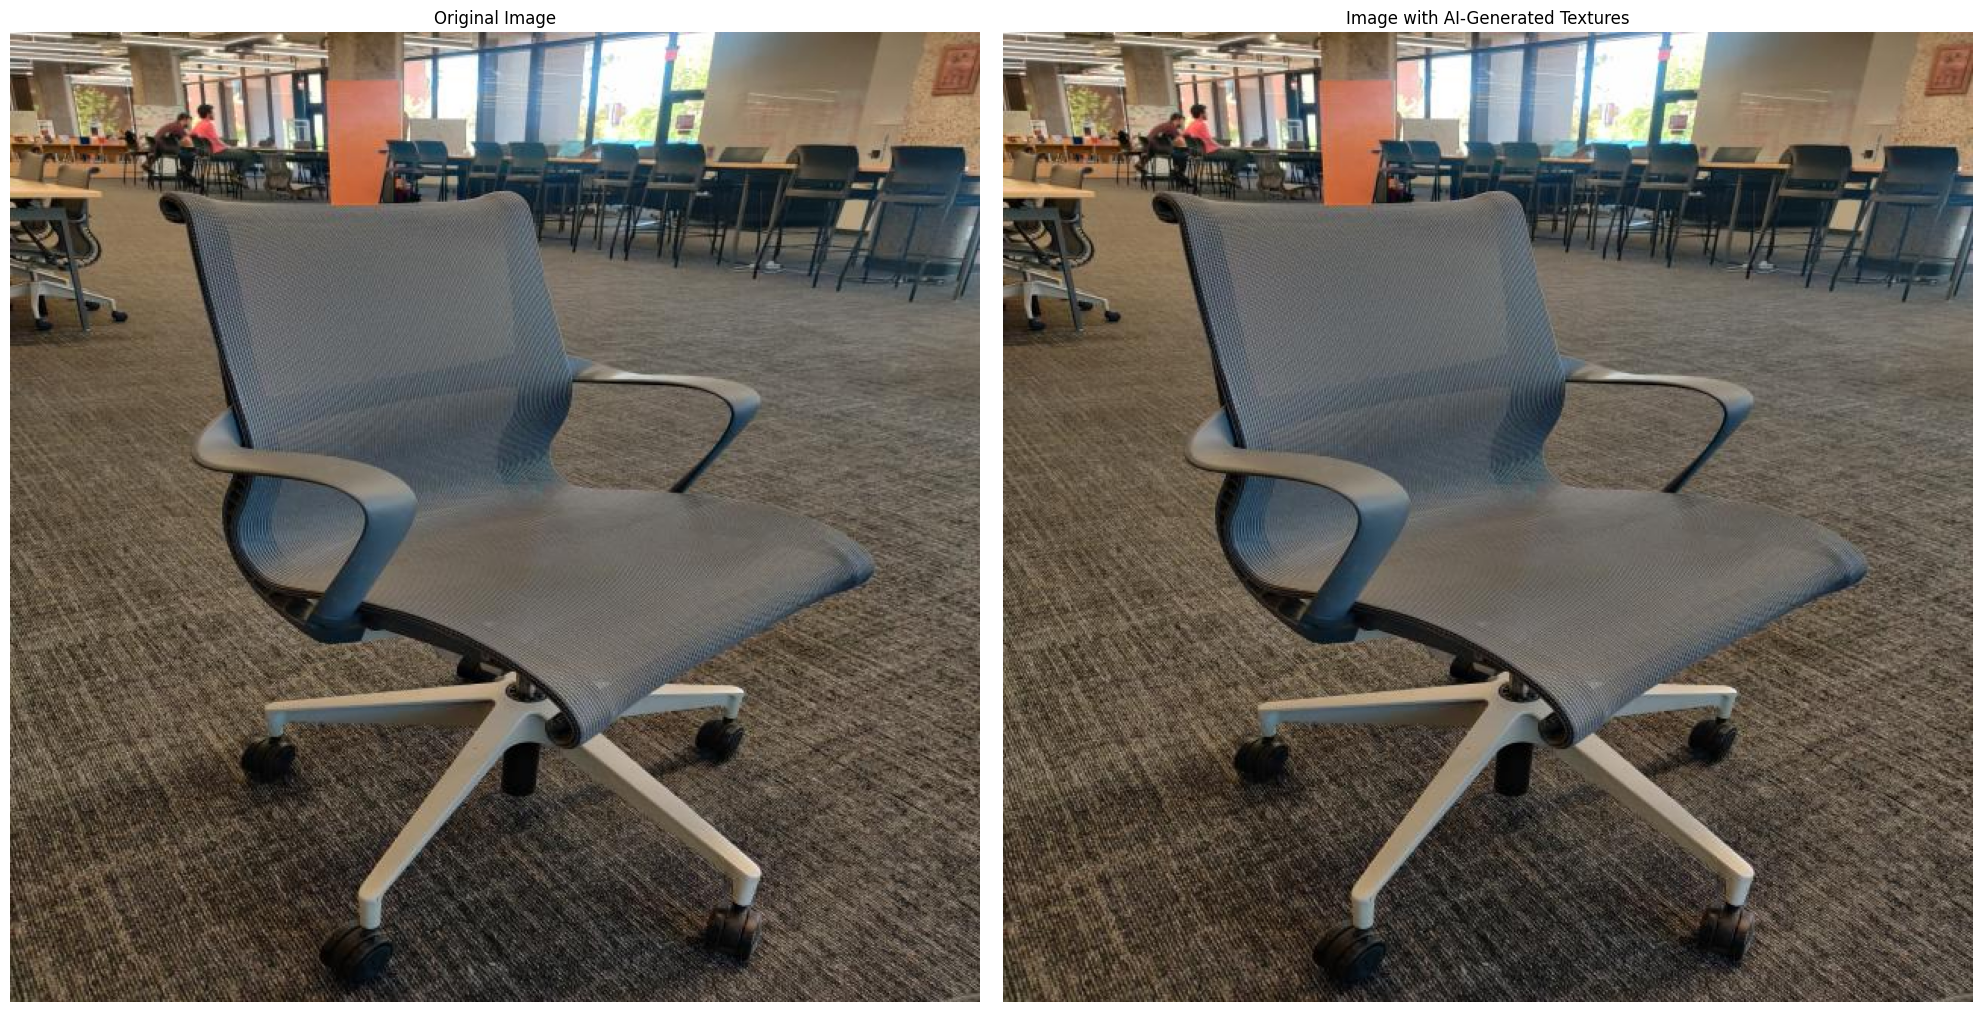

Prompts used for texture generation:
Auto-generated prompt: a photo of upholstery, describe the texture, material and surface details of an object that appears to be floating in the dark night sky, upholstery texture, detailed, realistic, high quality, photorealistic
Auto-generated prompt: a photo of upholstery, describe the texture, material and surface details of a chair that can be used as a seat or a cushion, upholstery texture, detailed, realistic, high quality, photorealistic
Auto-generated prompt: a photo of plastic, describe the texture, material and surface details of the earth ' s surface, including the moon, venus, and earth ' s atmosphere, plastic texture, detailed, realistic, high quality, photorealistic
Auto-generated prompt: a photo of plastic, describe the texture, material and surface details of an object that appears to be floating in the air with a black background behind it, plastic texture, detailed, realistic, high quality, photorealistic
Auto-generated prompt: a 

In [17]:
# Process another image
result = generate_textures_with_auto_prompts(1)
display_auto_results(1)

In [18]:
def generate_textures_only(image_idx=0):
    """Generate textures for segmented parts without applying them to the original image"""

    # Get dataset paths
    dataset_path = "/content/table-segmentation-1"
    test_dir = os.path.join(dataset_path, "test")
    images_dir = os.path.join(test_dir, "images")
    labels_dir = os.path.join(test_dir, "labels")

    # Define output path
    output_path = "./textures_only"
    os.makedirs(output_path, exist_ok=True)

    # List images
    image_files = sorted(glob.glob(os.path.join(images_dir, "*.jpg")) +
                         glob.glob(os.path.join(images_dir, "*.jpeg")) +
                         glob.glob(os.path.join(images_dir, "*.png")))

    if image_idx >= len(image_files):
        print(f"Error: Image index {image_idx} out of range. Only {len(image_files)} images available.")
        return None

    # Get image and label paths
    img_path = image_files[image_idx]
    img_name = os.path.basename(img_path)
    base_name = os.path.splitext(img_name)[0]
    label_path = os.path.join(labels_dir, base_name + '.txt')

    if not os.path.exists(label_path):
        print(f"Error: Label file not found: {label_path}")
        return None

    # Load image
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    img_height, img_width = image.shape[:2]

    # Create output directory
    img_output_dir = os.path.join(output_path, base_name)
    os.makedirs(img_output_dir, exist_ok=True)

    # Save original image
    Image.fromarray(image).save(os.path.join(img_output_dir, "original.png"))

    # Load masks
    masks, class_ids = read_yolo_seg_file(label_path, img_width, img_height)

    # Save a visualization of the segmentation
    plt.figure(figsize=(12, 8))
    plt.imshow(image)

    # Draw masks with different colors
    colors = plt.cm.tab20(np.linspace(0, 1, max(len(masks), 1)))
    for i, (mask, class_id) in enumerate(zip(masks, class_ids)):
        color_mask = np.zeros((img_height, img_width, 3))
        color_rgba = colors[i % len(colors)][:3]  # Get RGB part of RGBA
        for c in range(3):
            color_mask[:,:,c] = mask * color_rgba[c]

        plt.imshow(color_mask, alpha=0.5)

        # Get class name and add label
        class_name = class_names[class_id] if class_id < len(class_names) else f"Class {class_id}"

        # Find mask center for label placement
        y_indices, x_indices = np.where(mask > 0)
        if len(y_indices) > 0 and len(x_indices) > 0:
            center_y = int(np.mean(y_indices))
            center_x = int(np.mean(x_indices))
            plt.text(center_x, center_y, class_name, color='white',
                     fontsize=12, ha='center', va='center',
                     bbox=dict(facecolor='black', alpha=0.7))

    plt.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(img_output_dir, "segmentation_visualization.png"))
    plt.close()

    # Process each segment
    print(f"Generating textures for {len(masks)} segments in image {img_name}...")

    with open(os.path.join(img_output_dir, "textures_log.txt"), "w") as log_file:
        log_file.write(f"Processing image: {img_name}\n")
        log_file.write(f"Number of segments: {len(masks)}\n\n")

        # Generated textures collection
        textures = []

        for i, (mask, class_id) in enumerate(tqdm(zip(masks, class_ids), total=len(masks))):
            # Get class name
            class_name = class_names[class_id] if class_id < len(class_names) else f"class_{class_id}"

            log_file.write(f"Segment {i+1}: Class {class_id} ({class_name})\n")

            # Create masked image
            masked_image = image.copy()
            for c in range(3):
                masked_image[:, :, c] = masked_image[:, :, c] * mask

            # Save masked instance
            instance_path = os.path.join(img_output_dir, f"{class_name}_{i}_instance.png")
            Image.fromarray(masked_image).save(instance_path)

            # Generate auto prompt using image-to-text model
            prompt = generate_description_from_image(masked_image, class_name)
            log_file.write(f"  Auto-generated prompt: {prompt}\n")

            try:
                # Generate control images
                masked_pil = Image.fromarray(masked_image)
                depth_image = midas(masked_pil)
                edge_image = hed(masked_pil)

                # Save control images
                depth_path = os.path.join(img_output_dir, f"{class_name}_{i}_depth.png")
                edge_path = os.path.join(img_output_dir, f"{class_name}_{i}_edge.png")
                depth_image.save(depth_path)
                edge_image.save(edge_path)

                # Generate texture using ControlNet
                result = pipe(
                    prompt=prompt,
                    negative_prompt="blurry, distorted, low quality, lowres",
                    image=[depth_image, edge_image],
                    num_inference_steps=30,
                    guidance_scale=7.5,
                ).images[0]

                # Save the raw generated texture (without masking)
                texture_path = os.path.join(img_output_dir, f"{class_name}_{i}_texture.png")
                result.save(texture_path)
                log_file.write(f"  Texture generated and saved to: {texture_path}\n")

                # Also save a tileable version (by cropping the center)
                width, height = result.size
                min_dim = min(width, height)
                left = (width - min_dim) // 2
                top = (height - min_dim) // 2
                right = left + min_dim
                bottom = top + min_dim

                tileable = result.crop((left, top, right, bottom))
                tileable_path = os.path.join(img_output_dir, f"{class_name}_{i}_tileable_texture.png")
                tileable.save(tileable_path)
                log_file.write(f"  Tileable texture saved to: {tileable_path}\n")

                # Store the texture with its information
                textures.append({
                    "class_name": class_name,
                    "class_id": class_id,
                    "segment_id": i,
                    "prompt": prompt,
                    "texture_path": texture_path,
                    "tileable_path": tileable_path
                })

            except Exception as e:
                log_file.write(f"  Error generating texture: {str(e)}\n")
                print(f"Error processing segment {i} ({class_name}): {e}")

    # Create a texture catalog
    plt.figure(figsize=(15, 5 * max(1, (len(textures)+1)//2)))
    for i, texture_info in enumerate(textures):
        plt.subplot(max(1, (len(textures)+1)//2), 2, i+1)
        img = Image.open(texture_info["texture_path"])
        plt.imshow(np.array(img))
        plt.title(f"{texture_info['class_name']} (Segment {texture_info['segment_id']})")
        plt.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(img_output_dir, "texture_catalog.png"))
    plt.close()

    print(f"Generated {len(textures)} textures for image {img_name}")
    print(f"Results saved to: {img_output_dir}")

    return textures

Error: Image index 1 out of range. Only 0 images available.


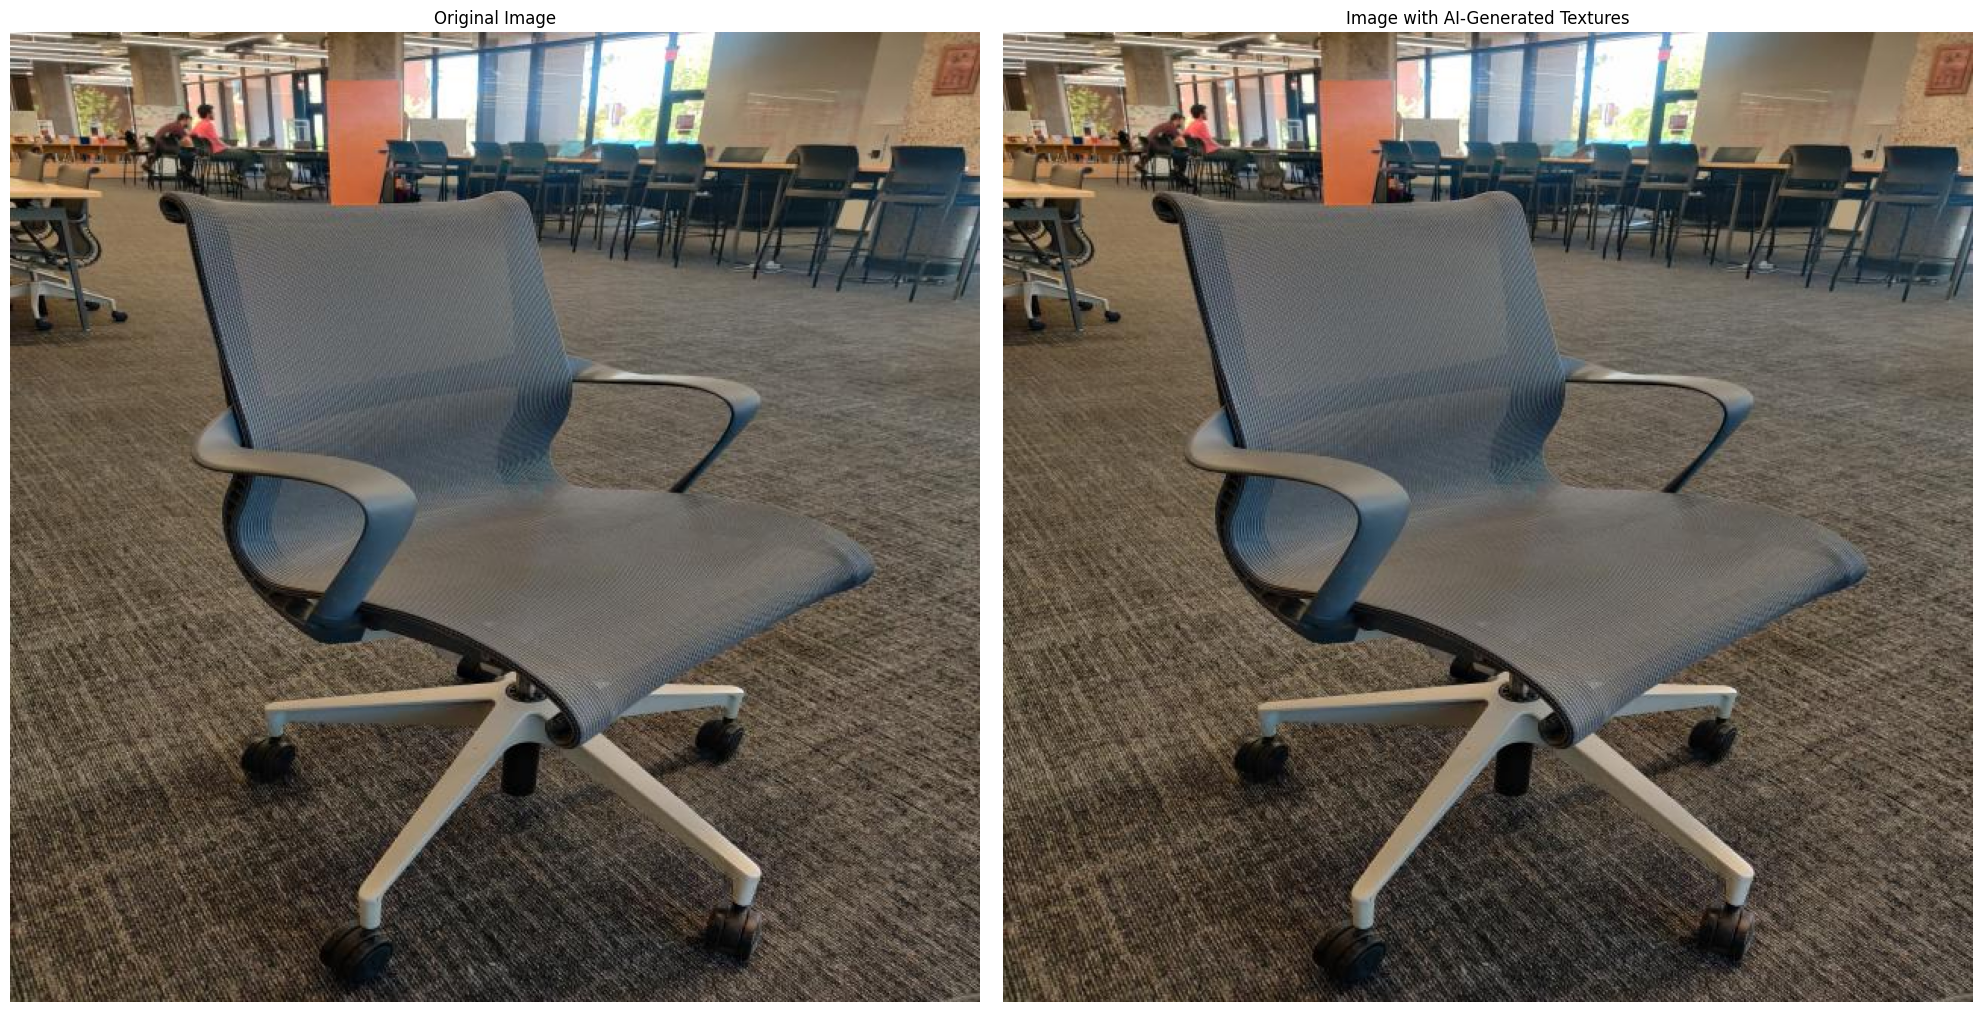

Prompts used for texture generation:
Auto-generated prompt: a photo of upholstery, describe the texture, material and surface details of an object that appears to be floating in the dark night sky, upholstery texture, detailed, realistic, high quality, photorealistic
Auto-generated prompt: a photo of upholstery, describe the texture, material and surface details of a chair that can be used as a seat or a cushion, upholstery texture, detailed, realistic, high quality, photorealistic
Auto-generated prompt: a photo of plastic, describe the texture, material and surface details of the earth ' s surface, including the moon, venus, and earth ' s atmosphere, plastic texture, detailed, realistic, high quality, photorealistic
Auto-generated prompt: a photo of plastic, describe the texture, material and surface details of an object that appears to be floating in the air with a black background behind it, plastic texture, detailed, realistic, high quality, photorealistic
Auto-generated prompt: a 

In [19]:
result = generate_textures_only(1)
display_auto_results(1)

In [20]:
def generate_pure_texture_swatches(image_idx=0, swatch_size=(512, 512)):
    """
    Generate pure texture swatches for each class without any mapping.
    Creates standalone texture samples organized by class.
    """

    # Get dataset paths
    dataset_path = "/content/table-segmentation-1"
    test_dir = os.path.join(dataset_path, "test")
    images_dir = os.path.join(test_dir, "images")
    labels_dir = os.path.join(test_dir, "labels")

    # Define output path
    output_path = "./pure_textures"
    os.makedirs(output_path, exist_ok=True)

    # List images
    image_files = sorted(glob.glob(os.path.join(images_dir, "*.jpg")) +
                         glob.glob(os.path.join(images_dir, "*.jpeg")) +
                         glob.glob(os.path.join(images_dir, "*.png")))

    if image_idx >= len(image_files):
        print(f"Error: Image index {image_idx} out of range. Only {len(image_files)} images available.")
        return None

    # Get image and label paths
    img_path = image_files[image_idx]
    img_name = os.path.basename(img_path)
    base_name = os.path.splitext(img_name)[0]
    label_path = os.path.join(labels_dir, base_name + '.txt')

    if not os.path.exists(label_path):
        print(f"Error: Label file not found: {label_path}")
        return None

    # Load image
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    img_height, img_width = image.shape[:2]

    # Load masks and class IDs
    masks, class_ids = read_yolo_seg_file(label_path, img_width, img_height)

    # Create a directory for class textures
    class_textures_dir = os.path.join(output_path, "class_textures")
    os.makedirs(class_textures_dir, exist_ok=True)

    # Create a log file
    with open(os.path.join(output_path, "textures_log.txt"), "w") as log_file:
        log_file.write("Pure Texture Generation Log\n")
        log_file.write("=========================\n\n")

        # Keep track of classes we've already processed
        processed_classes = set()

        # Process each unique class
        for mask, class_id in zip(masks, class_ids):
            # Get class name
            class_name = class_names[class_id] if class_id < len(class_names) else f"class_{class_id}"

            # Skip if we've already processed this class
            if class_id in processed_classes:
                continue

            processed_classes.add(class_id)

            log_file.write(f"Generating texture for class: {class_name} (ID: {class_id})\n")

            # Create a reference image that represents this class
            # We'll use the first instance of this class to guide the texture generation
            reference_image = image.copy()
            class_mask = np.zeros((img_height, img_width), dtype=np.uint8)

            # Combine all masks for this class
            for m, cid in zip(masks, class_ids):
                if cid == class_id:
                    class_mask = np.logical_or(class_mask, m).astype(np.uint8)

            # Apply mask to get reference image
            for c in range(3):
                reference_image[:, :, c] = reference_image[:, :, c] * class_mask

            # Generate auto prompt for this class
            prompt = generate_description_from_image(reference_image, class_name)
            # Enhance for pure texture
            prompt = f"seamless tileable texture of {class_name}, {prompt}, material sample, texture swatch, pure texture"

            log_file.write(f"  Prompt: {prompt}\n")

            try:
                # Generate control images from the reference
                reference_pil = Image.fromarray(reference_image)
                depth_image = midas(reference_pil)
                edge_image = hed(reference_pil)

                # Generate pure texture (no masking, full swatch)
                texture_result = pipe(
                    prompt=prompt,
                    negative_prompt="blurry, distorted, low quality, lowres, text, watermark, signature, frame, border",
                    image=[depth_image, edge_image],
                    num_inference_steps=40,  # More steps for higher quality
                    guidance_scale=7.5,
                    width=swatch_size[0],
                    height=swatch_size[1]
                ).images[0]

                # Save the pure texture swatch
                texture_path = os.path.join(class_textures_dir, f"{class_name}_texture.png")
                texture_result.save(texture_path)
                log_file.write(f"  Pure texture saved to: {texture_path}\n\n")

            except Exception as e:
                log_file.write(f"  Error generating texture: {str(e)}\n\n")
                print(f"Error processing class {class_name}: {e}")

    # Create a texture catalog
    texture_files = glob.glob(os.path.join(class_textures_dir, "*.png"))

    if texture_files:
        n_textures = len(texture_files)
        cols = min(3, n_textures)
        rows = (n_textures + cols - 1) // cols

        plt.figure(figsize=(5*cols, 5*rows))
        for i, texture_file in enumerate(texture_files):
            plt.subplot(rows, cols, i+1)

            # Get class name from filename
            texture_name = os.path.basename(texture_file).replace('_texture.png', '')

            # Load and display texture
            texture_img = Image.open(texture_file)
            plt.imshow(np.array(texture_img))
            plt.title(texture_name)
            plt.axis('off')

        plt.tight_layout()
        plt.savefig(os.path.join(output_path, "texture_catalog.png"))
        plt.close()

    print(f"Generated {len(processed_classes)} unique class textures")
    print(f"Results saved to: {class_textures_dir}")

    return texture_files

In [21]:
# Generate pure texture swatches for each class
texture_files = generate_pure_texture_swatches(0)

Error: Image index 0 out of range. Only 0 images available.


In [22]:
result